In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import matplotlib.pyplot as plt
import seaborn as sns
import data_processing
import random
import tensorflow as tf

In [2]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [3]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [4]:
def encode_time_features(year, month, day, hour):
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    day_sin = np.sin(2 * np.pi * day / 31)
    day_cos = np.cos(2 * np.pi * day / 31)
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    year_normalized = (year - 2004) / (20)
    return [year_normalized, month_sin, month_cos, day_sin, day_cos, hour_sin, hour_cos]

In [5]:
reload(data_processing)
import data_processing
from data_processing import preprocess_profile_data as ppd

In [6]:
date_indices = np.arange(len(h2o_data['year'].values))

In [7]:
features, labels, feature_date_indices = ppd('H2O', 
                                             h2o_data, 
                                             h2o_flags, 
                                             date_indices, 
                                             n_surrounding = 4, 
                                             n_altitudes = len(h2o_data['altitude'].values),
                                             filter_indices = True
                                             )

VMR for date index 256 is empty after screening
VMR for date index 1753 is empty after screening
VMR for date index 2319 is empty after screening
VMR for date index 2506 is empty after screening
VMR for date index 4293 is empty after screening
VMR for date index 4316 is empty after screening
VMR for date index 4591 is empty after screening
VMR for date index 4683 is empty after screening
VMR for date index 4695 is empty after screening
VMR for date index 4773 is empty after screening
VMR for date index 5448 is empty after screening
VMR for date index 5617 is empty after screening
VMR for date index 5743 is empty after screening
VMR for date index 6082 is empty after screening
VMR for date index 6844 is empty after screening
VMR for date index 7916 is empty after screening
VMR for date index 7917 is empty after screening
VMR for date index 7977 is empty after screening
VMR for date index 7989 is empty after screening
VMR for date index 8142 is empty after screening
VMR for date index 83

In [8]:
features.shape

(125194, 5, 150, 11)

In [9]:
labels.shape
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(124340), np.int64(1): np.int64(854)}


In [10]:
from keras import layers, models

In [11]:
import tensorflow as tf

def binary_accuracy_with_threshold(y_true, y_pred):
    """
    Custom accuracy metric for binary classification with a threshold.
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    return tf.keras.metrics.binary_accuracy(y_true, y_pred_discrete)

In [57]:
from keras.optimizers import Adam
from keras.regularizers import l2

# Define the CNN-LSTM model
def build_cnn_lstm_model(n_profiles, n_altitudes, n_features):
    """
    Builds a CNN-LSTM model for profile classification.

    Parameters:
    - n_profiles: Number of profiles per sample.
    - n_altitudes: Number of altitude levels per profile.
    - n_features: Number of features per altitude.

    Returns:
    - model: Compiled CNN-LSTM model.
    """
    input_shape = (n_profiles, n_altitudes, n_features)

    # Input layer
    inputs = tf.keras.Input(shape=input_shape)

    # Time-distributed CNN layers
    cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_altitudes, n_features), kernel_regularizer=l2(1e-4)),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(filters=128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
            layers.MaxPooling1D(pool_size=2),
            layers.Flatten()
        ])
    )(inputs)

    # LSTM layers
    lstm = layers.LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4))(cnn)

    # Attention Layer
    attention = layers.Attention()([lstm, lstm]) # Self-attention: query and key/value are the same
    attention_output = layers.GlobalAveragePooling1D()(attention)  # Aggregate along profiles

    # Fully connected layers
    dense = layers.Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(attention_output)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(1e-4))(dense)  # Binary classification

    # Build the model
    model = models.Model(inputs=inputs, outputs=outputs)

    # Compile the model
    optimizer = Adam(learning_rate=1e-4)  # Lower the learning rate
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[binary_accuracy_with_threshold])

    return model


In [58]:
n_profiles = 5
n_altitudes = len(h2o_data['altitude'].values)
n_features = 11

model = build_cnn_lstm_model(n_profiles, n_altitudes, n_features)

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
from keras._tf_keras.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [60]:
# Split the data into training, validation, and test sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [61]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [140]:
import numpy as np

# Compute raw class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Apply logarithmic scaling
smoothed_weights = np.log1p(class_weights)

# Convert to dictionary for Keras
class_weights_dict = {i: smoothed_weights[i] for i in range(len(smoothed_weights))}

In [141]:
intermediate_weights = (class_weights + smoothed_weights)/2

class_weights_dict = {i: intermediate_weights[i] for i in range(len(intermediate_weights))}

Epoch 1/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 98s 67ms/step - binary_accuracy_with_threshold: 0.5576 - loss: 0.8178 - val_binary_accuracy_with_threshold: 0.4943 - val_loss: 0.7747
Epoch 2/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 95s 70ms/step - binary_accuracy_with_threshold: 0.6281 - loss: 0.7392 - val_binary_accuracy_with_threshold: 0.0687 - val_loss: 0.8314
Epoch 3/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 98s 72ms/step - binary_accuracy_with_threshold: 0.2780 - loss: 0.7805 - val_binary_accuracy_with_threshold: 0.8840 - val_loss: 0.6155
Epoch 4/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 99s 72ms/step - binary_accuracy_with_threshold: 0.6526 - loss: 0.7136 - val_binary_accuracy_with_threshold: 0.7094 - val_loss: 0.6655
Epoch 5/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 98s 71ms/step - binary_accuracy_with_threshold: 0.5862 - loss: 0.7211 - val_binary_accuracy_with_threshold: 0.8311 - val_loss: 0.6043
Epoch 6/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 99s 72ms/step - binary_accuracy_with_threshold: 0.5645 - loss: 0.7175 - val_bi

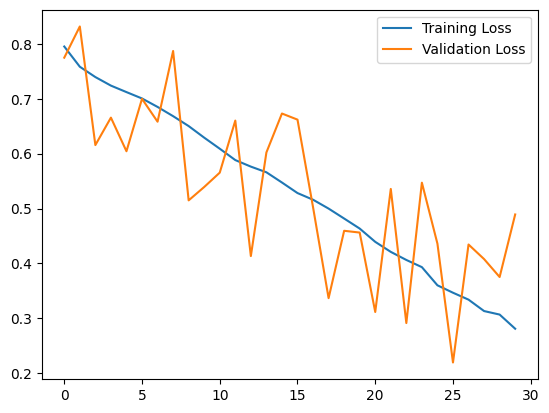

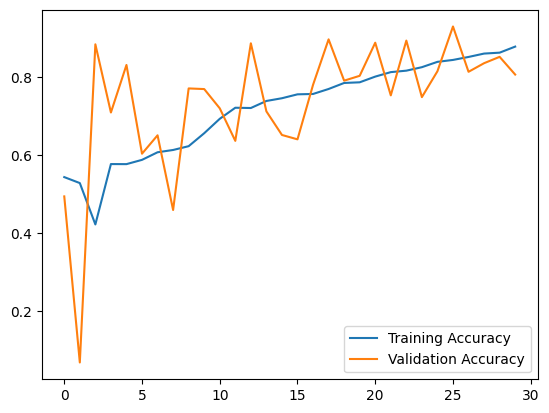

In [62]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict
)

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['binary_accuracy_with_threshold'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy_with_threshold'], label='Validation Accuracy')
plt.legend()
plt.show()

587/587 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
              precision    recall  f1-score   support

           0       1.00      0.94      0.96     18655
           1       0.03      0.32      0.06       125

    accuracy                           0.93     18780
   macro avg       0.51      0.63      0.51     18780
weighted avg       0.99      0.93      0.96     18780



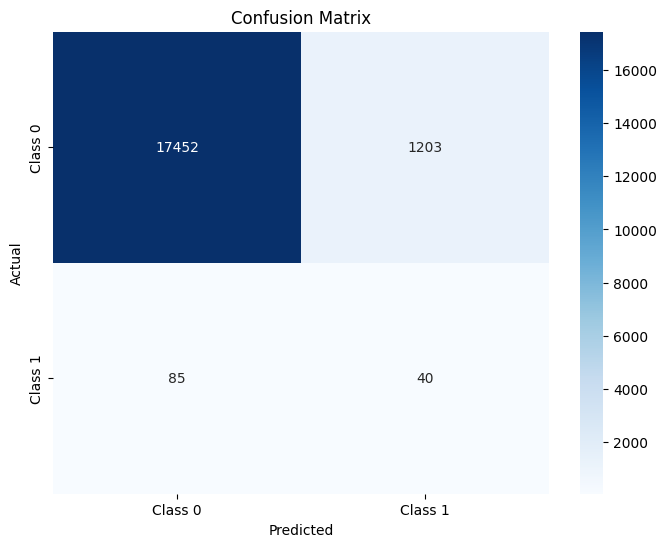

In [63]:
# Get predictions
predictions = model.predict(X_test)

# Convert probabilities to discrete labels
discrete_predictions = (predictions > 0.5).astype(int)

# Print classification report
print(classification_report(y_test, discrete_predictions))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, discrete_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

(1000, 5, 150, 11)


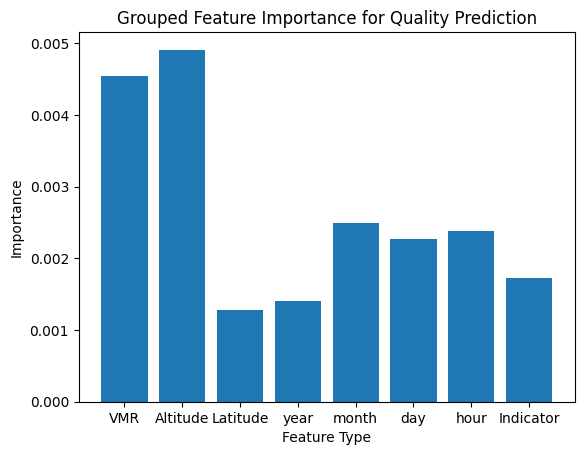

In [64]:

random_indices = np.random.choice(X_test.shape[0], 1000, replace=False)
X_test_sample = X_test[random_indices]

def compute_saliency(model, X):
    X_tensor = tf.convert_to_tensor(X)
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model(X_tensor)

    gradients = tape.gradient(predictions, X_tensor)
    return np.abs(gradients.numpy())

saliency = compute_saliency(model, X_test_sample)
print(saliency.shape)

# Aggregate over features
feature_importance = np.mean(saliency, axis=(0, 1, 2))  # Aggregate over profiles and altitudes
n_altitudes = 150
n_features = 11

feature_groups = {
    "VMR": feature_importance[0],
    "Altitude": feature_importance[1],
    "Latitude": feature_importance[2],
    "year": feature_importance[3],
    "month": np.sum(feature_importance[4:6]),
    "day": np.sum(feature_importance[6:8]),
    "hour": np.sum(feature_importance[8:10]),
    #"Time Features": np.sum(feature_importance[3:10]),  # Sum of 7 time features
    "Indicator": feature_importance[10],
}

# Visualize grouped feature importance
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel("Feature Type")
plt.ylabel("Importance")
plt.title("Grouped Feature Importance for Quality Prediction")
plt.show()

In [24]:
predicted_bad_indices = np.where(discrete_predictions == 1)[0]

1269


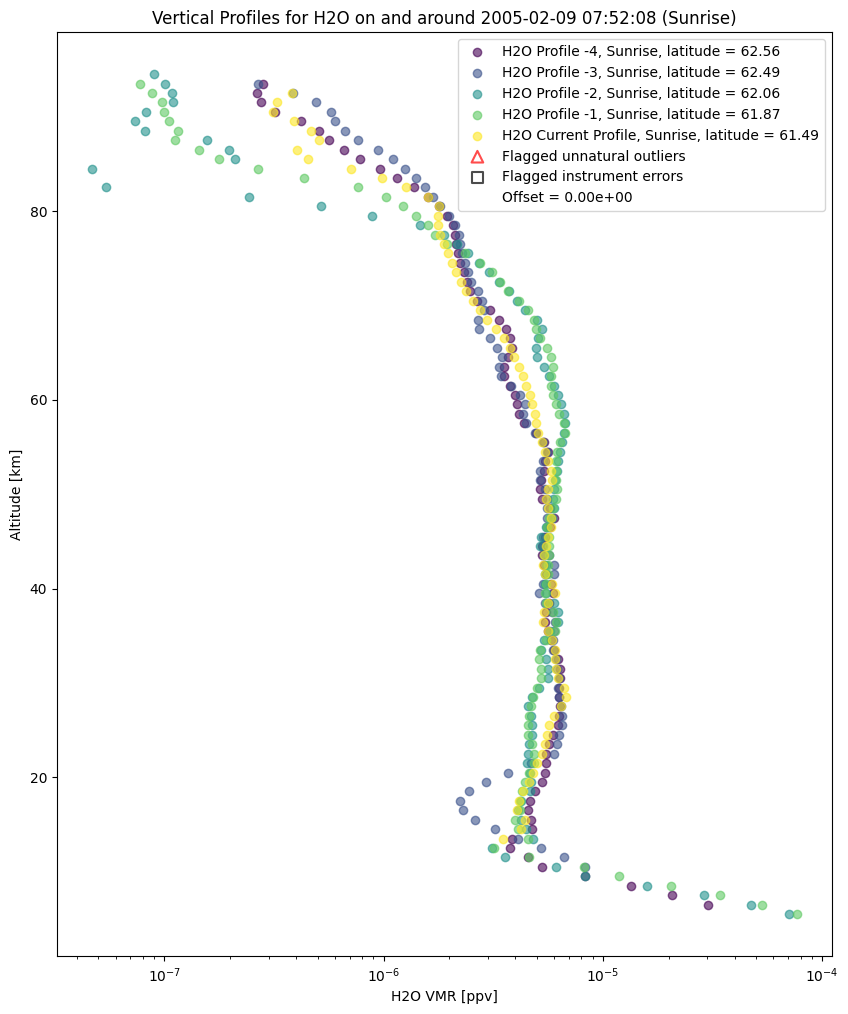

In [107]:
reload(data_processing)
from data_processing import vertical_profile_plot as vpp
#18612
idx = np.random.choice(predicted_bad_indices)
print(idx)

date_indices_example = feature_date_indices[idx]

vpp('H2O', h2o_data, h2o_flags, date_indices_example)

In [71]:
print(date_indices_example)

[1057 1058 1059 1060 1061]


In [38]:
print(h2o_data['sunset_sunrise'].values[18727])

1.0


In [33]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

587/587 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - binary_accuracy_with_threshold: 0.8518 - loss: 0.4360
Test Loss: 0.43780452013015747, Test Accuracy: 0.8483493328094482


In [54]:
from tabulate import tabulate

In [56]:
years = h2o_data['year'].values

unique, counts = np.unique(years, return_counts=True)
print(tabulate(dict(zip(unique, counts)).items(), headers=["Year", "Number of samples"], tablefmt="grid"))

+--------+---------------------+
|   Year |   Number of samples |
+========+=====================+
|   2004 |                2727 |
+--------+---------------------+
|   2005 |                5647 |
+--------+---------------------+
|   2006 |                4543 |
+--------+---------------------+
|   2007 |                4432 |
+--------+---------------------+
|   2008 |                5453 |
+--------+---------------------+
|   2009 |                6195 |
+--------+---------------------+
|   2010 |                6149 |
+--------+---------------------+
|   2011 |                6269 |
+--------+---------------------+
|   2012 |                5998 |
+--------+---------------------+
|   2013 |                5237 |
+--------+---------------------+
|   2014 |                5794 |
+--------+---------------------+
|   2015 |                6129 |
+--------+---------------------+
|   2016 |                6773 |
+--------+---------------------+
|   2017 |                7527 |
+--------+

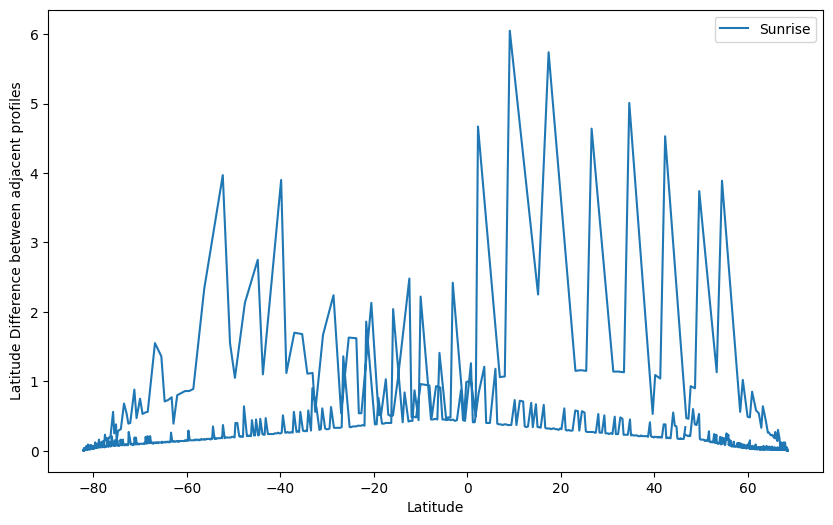

In [103]:
sorted_indices = np.argsort(times.to_numpy())

sorted_years = h2o_data['year'].values[sorted_indices]

sorted_latitudes = h2o_data['latitude'].values[sorted_indices]

start_index = np.where(h2o_data['year'].values[sorted_indices] == 2017)[0][0]
end_index = np.where(h2o_data['year'].values[sorted_indices] == 2018)[0][0]

#start_index = 0
#end_index = len(sorted_latitudes)
end_index = start_index + 2760

sunset_latitudes = [sorted_latitudes[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [0, 2]]
sunrise_latitudes = [sorted_latitudes[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [1, 3]]

sunset_diff = np.abs(np.diff(sunset_latitudes))
sunrise_diff = np.abs(np.diff(sunrise_latitudes))

plt.figure(figsize=(10, 6))
#plt.plot(sunset_latitudes[1:len(sunset_latitudes)], sunset_diff, label = 'Sunset')
plt.plot(sunrise_latitudes[1:len(sunrise_latitudes)], sunrise_diff, label = 'Sunrise')
plt.xlabel('Latitude')
plt.ylabel('Latitude Difference between adjacent profiles')
plt.legend()
plt.show()




In [105]:
sorted_times = times.to_numpy()[sorted_indices]

time_diff = sorted_times[end_index] - sorted_times[start_index]
print(sorted_times[start_index], sorted_times[end_index])
print(time_diff.astype('timedelta64[D]').item().days)

print((time_diff/2760).astype('timedelta64[m]'))

2017-01-01T03:37:06.250000000 2017-05-10T23:19:26.280000001
129
67 minutes


Text(0, 0.5, 'Latitude')

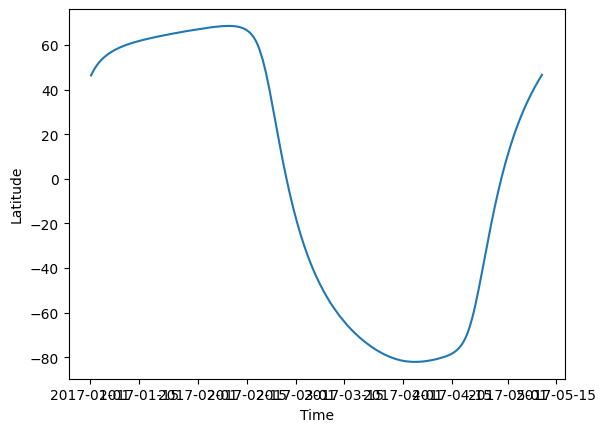

In [107]:
sunrise_times = [sorted_times[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [1, 3]]

plt.plot(sunrise_times, sunrise_latitudes)
plt.xlabel('Time')
plt.ylabel('Latitude')